# Business Sales Performance Analytics 

Welcome! This notebook guides you through a client-ready analytics workflow for business sales performance. It’s designed for beginners but follows professional standards used in real projects.

What you’ll do:
- Clean and prepare raw sales data (handle missing values, duplicates, types, and outliers)
- Analyze sales & profit trends over time
- Identify top products, categories, and regions
- Compute KPIs (Revenue, Profit, Margin, AOV, etc.)
- Generate insights and actionable recommendations
- Save clean data, KPIs, and figures for a dashboard (Power BI/Tableau/Excel)

Dataset expectations (flexible; code adapts):
- Columns (common examples): Order Date, Order ID, Product, Category, Sub-Category, Region, Customer ID, Quantity, Unit Price, Discount, Unit Cost, Sales, Profit, Revenue
- If your file is missing, the notebook generates a realistic sample so it runs end-to-end

How to use:
1) Put your CSV at data/sales.csv (or keep sample)
2) Run cells top-to-bottom
3) Check outputs in reports/ and data/
4) Use the Dashboard Guidance section to build a client-ready dashboard

In [1]:
# 1) Project Setup and Configuration (Paths, Params, Seeding)
from __future__ import annotations
import os
from pathlib import Path
from datetime import datetime, timedelta
import json
import random

RUN_TS = datetime.utcnow().strftime('%Y%m%d_%H%M%S')
BASE_DIR = Path.cwd().parent if (Path.cwd().name == 'notebooks') else Path.cwd()
CONFIG = {
    'data_path': str(BASE_DIR / 'data' / 'sales.csv'),
    'sample_path': str(BASE_DIR / 'data' / 'sales_sample.csv'),
    'processed_dir': str(BASE_DIR / 'data'),
    'reports_dir': str(BASE_DIR / 'reports'),
    'figures_dir': str(BASE_DIR / 'reports' / 'figures'),
    'start_date': None,  # e.g., '2021-01-01'
    'end_date': None,    # e.g., '2023-12-31'
    'currency': 'USD',
    'timezone': 'UTC',
    'run_ts': RUN_TS,
}

# Create folders if missing
Path(CONFIG['processed_dir']).mkdir(parents=True, exist_ok=True)
Path(CONFIG['reports_dir']).mkdir(parents=True, exist_ok=True)
Path(CONFIG['figures_dir']).mkdir(parents=True, exist_ok=True)

# Seeding for reproducibility
SEED = 42
random.seed(SEED)

print('Run Metadata:')
print(json.dumps({k: v for k, v in CONFIG.items() if k not in ['data_path','sample_path']}, indent=2))
print(f"Base Directory: {BASE_DIR}")

Run Metadata:
{
  "processed_dir": "c:\\Users\\AYUSHITIWARI\\FUTURE_DS_01\\data",
  "reports_dir": "c:\\Users\\AYUSHITIWARI\\FUTURE_DS_01\\reports",
  "figures_dir": "c:\\Users\\AYUSHITIWARI\\FUTURE_DS_01\\reports\\figures",
  "start_date": null,
  "end_date": null,
  "currency": "USD",
  "timezone": "UTC",
  "run_ts": "20260123_090445"
}
Base Directory: c:\Users\AYUSHITIWARI\FUTURE_DS_01


C:\Users\AYUSHITIWARI\AppData\Local\Temp\ipykernel_5944\1486314030.py:9: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  RUN_TS = datetime.utcnow().strftime('%Y%m%d_%H%M%S')


In [5]:
# 2) Import Libraries and Set Options
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
import plotly
from dateutil import parser as date_parser
import warnings
import pyarrow as pa
import pyarrow.parquet as pq
import scipy
import statsmodels.api as sm
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 100)
pd.set_option('display.width', 120)
sns.set_theme(style='whitegrid')

print('Versions:')
print({'pandas': pd.__version__, 'numpy': np.__version__, 'seaborn': sns.__version__,
       'matplotlib': plt.matplotlib.__version__, 'plotly': plotly.__version__, 'pyarrow': pa.__version__,
       'scipy': scipy.__version__, 'statsmodels': sm.__version__})

Versions:
{'pandas': '3.0.0', 'numpy': '2.4.1', 'seaborn': '0.13.2', 'matplotlib': '3.10.8', 'plotly': '6.5.2', 'pyarrow': '23.0.0', 'scipy': '1.17.0', 'statsmodels': '0.14.6'}


In [6]:
# 3) Define Data Schema and Load Raw Data
from typing import Dict, List

REQUIRED_SCHEMA = {
    'order_id': 'string',
    'order_date': 'datetime64[ns]','customer_id': 'string','product_id': 'string',
    'category': 'string','region': 'string','channel': 'string','quantity': 'int64',
    'unit_price': 'float64','discount_rate': 'float64','unit_cost': 'float64'
}

RAW_PATH = Path(CONFIG['data_path'])
SAMPLE_PATH = Path(CONFIG['sample_path'])

# Helper: standardize column names
def to_snake(s: str) -> str:
    return (
        s.strip().lower().replace(' ', '_').replace('-', '_').replace('/', '_')
    )

# Synthetic data generator (used if no real file exists)
def generate_sample_csv(path: Path, n_rows: int = 1500, seed: int = 42):
    rng = np.random.default_rng(seed)
    start = datetime(2023, 1, 1)
    dates = [start + timedelta(days=int(x)) for x in rng.integers(0, 720, size=n_rows)]
    categories = ['Technology', 'Office Supplies', 'Furniture']
    regions = ['East', 'West', 'Central', 'South']
    channels = ['Online', 'Retail']

    df = pd.DataFrame({
        'order_id': [f'ORD{100000+x}' for x in range(n_rows)],
        'order_date': dates,
        'customer_id': [f'C{rng.integers(1000, 9999)}' for _ in range(n_rows)],
        'product_id': [f'P{rng.integers(100, 999)}' for _ in range(n_rows)],
        'category': rng.choice(categories, size=n_rows),
        'region': rng.choice(regions, size=n_rows),
        'channel': rng.choice(channels, size=n_rows, p=[0.7, 0.3]),
        'quantity': rng.integers(1, 10, size=n_rows),
        'unit_price': np.round(rng.uniform(5, 500, size=n_rows), 2),
        'discount_rate': np.clip(np.round(rng.normal(0.1, 0.08, size=n_rows), 2), 0, 0.6),
        'unit_cost': lambda: None
    })
    # Compute unit_cost as a fraction of price to ensure positive margins on average
    df['unit_cost'] = np.round(df['unit_price'] * rng.uniform(0.4, 0.85, size=n_rows), 2)
    # Randomly introduce a few missing values
    mask = rng.choice([True, False], size=n_rows, p=[0.02, 0.98])
    df.loc[mask, 'discount_rate'] = np.nan

    path.parent.mkdir(parents=True, exist_ok=True)
    df.to_csv(path, index=False)
    return path


def load_data(path: Path) -> pd.DataFrame:
    if not path.exists():
        print(f"Data file not found at {path}. Generating a sample dataset at {SAMPLE_PATH} ...")
        generate_sample_csv(SAMPLE_PATH)
        path = SAMPLE_PATH

    df = pd.read_csv(path)
    # Standardize column names and trim strings
    df.columns = [to_snake(c) for c in df.columns]
    for c in df.select_dtypes(include=['object']).columns:
        df[c] = df[c].astype('string').str.strip()

    # Map possible alternative names to required schema
    col_map = {
        'orderdate': 'order_date','order_date': 'order_date','order id': 'order_id','orderid': 'order_id',
        'product': 'product_id','product_id': 'product_id','sub-category': 'category','subcategory': 'category',
        'category': 'category','region': 'region','segment': 'channel','channel': 'channel','customer_id':'customer_id',
        'qty': 'quantity','quantity': 'quantity','sales': 'unit_price','unit_price':'unit_price','discount':'discount_rate','discount_rate':'discount_rate',
        'unit_cost':'unit_cost','cost':'unit_cost'
    }
    df = df.rename(columns={k: v for k, v in col_map.items() if k in df.columns})

    # Enforce required columns
    missing = [c for c in REQUIRED_SCHEMA if c not in df.columns]
    if missing:
        raise ValueError(f"Missing required columns: {missing}. Please align your file's columns.")

    # Parse dates and dtypes
    df['order_date'] = pd.to_datetime(df['order_date'], errors='coerce')
    for col, dtype in REQUIRED_SCHEMA.items():
        if col == 'order_date':
            continue
        if dtype.startswith('int'):
            df[col] = pd.to_numeric(df[col], errors='coerce').astype('Int64')
        elif dtype.startswith('float'):
            df[col] = pd.to_numeric(df[col], errors='coerce')
        elif dtype == 'string':
            df[col] = df[col].astype('string')

    return df

raw_df = load_data(RAW_PATH)
print('Loaded rows:', len(raw_df))
raw_df.head(3)

Data file not found at c:\Users\AYUSHITIWARI\FUTURE_DS_01\data\sales.csv. Generating a sample dataset at c:\Users\AYUSHITIWARI\FUTURE_DS_01\data\sales_sample.csv ...
Loaded rows: 1500


,order_id,order_date,customer_id,product_id,category,region,channel,quantity,unit_price,discount_rate,unit_cost
0,ORD100000,2023-03-06,C5767,P799,Furniture,Central,Online,1,230.46,0.10,146.53
1,ORD100001,2024-07-11,C3342,P703,Office Supplies,South,Online,5,63.83,0.00,47.39
2,ORD100002,2024-04-16,C3060,P936,Furniture,Central,Online,6,286.74,0.09,221.40


Shape: (1500, 11)

Nulls per column:
discount_rate    19
order_date        0
order_id          0
customer_id       0
product_id        0
region            0
category          0
channel           0
quantity          0
unit_price        0
unit_cost         0
dtype: int64

Distinct counts (head):
order_id         1500
unit_price       1477
unit_cost        1470
customer_id      1381
product_id        720
order_date        629
discount_rate      34
quantity            9
region              4
category            3
dtype: int64

Exact duplicate rows: 0
Duplicate (order_id, product_id) lines: 0


,count,mean,min,1%,5%,50%,95%,99%,max,std
order_date,1500,2023-12-29 21:51:21.600000,2023-01-01 00:00:00,2023-01-06 00:00:00,2023-02-06 00:00:00,2023-12-30 00:00:00,2024-11-17 01:12:00,2024-12-14 00:00:00,2024-12-20 00:00:00,NaN
quantity,1500.0,5.054667,1.0,1.0,1.0,5.0,9.0,9.0,9.0,2.544273
unit_price,1500.0,250.394293,5.21,9.1817,27.1525,250.345,476.9915,495.362,499.99,142.006543
discount_rate,1481.0,0.102748,0.0,0.0,0.0,0.1,0.22,0.272,0.42,0.071748
unit_cost,1500.0,156.176613,2.2,5.2488,16.6055,147.365,332.138,380.8799,408.08,96.75276


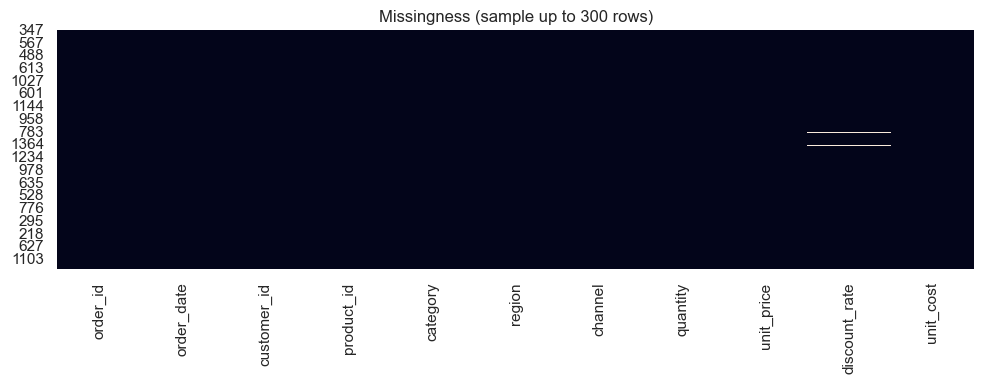


Summary for stakeholders:
- Data rows:  1500
- Missing values present in key fields? Check counts above
- Duplicate lines and order-level duplicates flagged


In [7]:
# 4) Quick Data Quality Report
print('Shape:', raw_df.shape)
print('\nNulls per column:')
print(raw_df.isna().sum().sort_values(ascending=False))

print('\nDistinct counts (head):')
print(raw_df.nunique().sort_values(ascending=False).head(10))

# Duplicate checks
print('\nExact duplicate rows:', raw_df.duplicated().sum())
if {'order_id','product_id'}.issubset(raw_df.columns):
    print('Duplicate (order_id, product_id) lines:', raw_df.duplicated(subset=['order_id','product_id']).sum())

# Basic numeric stats
display(raw_df.describe(percentiles=[.01,.05,.5,.95,.99]).T)

# Missingness heatmap (optionally comment if large)
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(10,4))
sns.heatmap(raw_df.sample(min(len(raw_df), 300)).isna(), cbar=False)
plt.title('Missingness (sample up to 300 rows)')
plt.tight_layout()
plt.show()

print('\nSummary for stakeholders:')
print('- Data rows: ', len(raw_df))
print('- Missing values present in key fields? Check counts above')
print('- Duplicate lines and order-level duplicates flagged')

In [8]:
# 5) Clean and Transform Data
clean_df = raw_df.copy()

# Remove exact duplicates
before = len(clean_df)
clean_df = clean_df.drop_duplicates()
print(f"Removed exact duplicates: {before - len(clean_df)}")

# Drop rows missing critical fields
critical = ['order_id','order_date']
missing_critical = clean_df[critical].isna().any(axis=1).sum()
clean_df = clean_df.dropna(subset=critical)
print(f"Dropped rows missing critical fields: {missing_critical}")

# Impute/clip numeric columns
num_cols = ['quantity','unit_price','discount_rate','unit_cost']
for c in num_cols:
    if c in clean_df.columns:
        if c == 'discount_rate':
            clean_df[c] = pd.to_numeric(clean_df[c], errors='coerce')
            clean_df[c] = clean_df[c].clip(lower=0, upper=1)
            clean_df[c] = clean_df[c].fillna(0.0)
        elif c == 'quantity':
            clean_df[c] = pd.to_numeric(clean_df[c], errors='coerce').fillna(0).astype('int64')
            clean_df = clean_df[clean_df[c] > 0]
        else:
            median_val = pd.to_numeric(clean_df[c], errors='coerce').median()
            clean_df[c] = pd.to_numeric(clean_df[c], errors='coerce').fillna(median_val)

# Normalize categories
for c in ['category','region','channel']:
    if c in clean_df.columns:
        clean_df[c] = clean_df[c].astype('string').str.strip().str.title()

# Type fixes
clean_df['order_date'] = pd.to_datetime(clean_df['order_date'], errors='coerce')
clean_df = clean_df.dropna(subset=['order_date'])

# Outlier handling via winsorization (1st/99th percentiles) for price/cost
for c in ['unit_price','unit_cost']:
    if c in clean_df.columns:
        lo, hi = clean_df[c].quantile([0.01, 0.99])
        clean_df[c] = clean_df[c].clip(lo, hi)

print('Cleaning complete. Rows now:', len(clean_df))

Removed exact duplicates: 0
Dropped rows missing critical fields: 0
Cleaning complete. Rows now: 1500


In [9]:
# 6) Derive Business Columns
fe_df = clean_df.copy()

# Date parts
fe_df['year'] = fe_df['order_date'].dt.year
fe_df['quarter'] = fe_df['order_date'].dt.to_period('Q').astype(str)
fe_df['month'] = fe_df['order_date'].dt.to_period('M').astype(str)
fe_df['week'] = fe_df['order_date'].dt.isocalendar().week.astype(int)
fe_df['dow'] = fe_df['order_date'].dt.day_name()

# Revenue and Cost math
fe_df['net_price'] = fe_df['unit_price'] * (1 - fe_df['discount_rate'])
fe_df['line_revenue'] = fe_df['quantity'] * fe_df['net_price']
fe_df['line_cogs'] = fe_df['quantity'] * fe_df['unit_cost']
fe_df['gross_profit'] = fe_df['line_revenue'] - fe_df['line_cogs']
fe_df['margin_pct'] = np.where(fe_df['line_revenue']>0, fe_df['gross_profit']/fe_df['line_revenue'], np.nan)

# Order-level metrics
order_agg = fe_df.groupby('order_id', as_index=False).agg(
    order_revenue=('line_revenue','sum'),
    order_gp=('gross_profit','sum'),
    order_qty=('quantity','sum'),
    order_date=('order_date','min'),
    customer_id=('customer_id','first')
)

# Optional reporting window filter
if CONFIG['start_date']:
    order_agg = order_agg[order_agg['order_date'] >= pd.to_datetime(CONFIG['start_date'])]
if CONFIG['end_date']:
    order_agg = order_agg[order_agg['order_date'] <= pd.to_datetime(CONFIG['end_date'])]

print('Feature engineering complete:')
print('Line-level rows:', len(fe_df), '| Order-level rows:', len(order_agg))
fe_df.head(3)

Feature engineering complete:
Line-level rows: 1500 | Order-level rows: 1500


,order_id,order_date,customer_id,product_id,category,region,channel,quantity,unit_price,discount_rate,unit_cost,year,quarter,month,week,dow,net_price,line_revenue,line_cogs,gross_profit,margin_pct
0,ORD100000,2023-03-06,C5767,P799,Furniture,Central,Online,1,230.46,0.10,146.53,2023,2023Q1,2023-03,10,Monday,207.4140,207.4140,146.53,60.8840,0.293539
1,ORD100001,2024-07-11,C3342,P703,Office Supplies,South,Online,5,63.83,0.00,47.39,2024,2024Q3,2024-07,28,Thursday,63.8300,319.1500,236.95,82.2000,0.257559
2,ORD100002,2024-04-16,C3060,P936,Furniture,Central,Online,6,286.74,0.09,221.40,2024,2024Q2,2024-04,16,Tuesday,260.9334,1565.6004,1328.40,237.2004,0.151508


In [11]:
# 7) Persist Clean Dataset
run_tag = CONFIG['run_ts']
line_path_parquet = Path(CONFIG['processed_dir'])/f'processed_sales_line_{run_tag}.parquet'
order_path_parquet = Path(CONFIG['processed_dir'])/f'processed_sales_order_{run_tag}.parquet'
line_path_csv = Path(CONFIG['processed_dir'])/f'processed_sales_line_{run_tag}.csv'
order_path_csv = Path(CONFIG['processed_dir'])/f'processed_sales_order_{run_tag}.csv'

parquet_ok = True
try:
    fe_df.to_parquet(line_path_parquet, index=False)
    order_agg.to_parquet(order_path_parquet, index=False)
except Exception as e:
    parquet_ok = False
    print('Parquet write failed; falling back to CSV only:', e)

fe_df.to_csv(line_path_csv, index=False)
order_agg.to_csv(order_path_csv, index=False)

manifest = {
    'run_ts': run_tag,
    'line_rows': int(len(fe_df)),
    'order_rows': int(len(order_agg)),
    'line_path_parquet': str(line_path_parquet) if parquet_ok else None,
    'order_path_parquet': str(order_path_parquet) if parquet_ok else None,
    'line_path_csv': str(line_path_csv),
    'order_path_csv': str(order_path_csv),
}
with open(Path(CONFIG['processed_dir'])/f'manifest_{run_tag}.json','w') as f:
    json.dump(manifest, f, indent=2)

print('Saved processed datasets and manifest.')

Parquet write failed; falling back to CSV only: A type extension with name pandas.period already defined
Saved processed datasets and manifest.


In [12]:
# 8) Compute Core KPIs
kpis = {}

kpis['total_revenue'] = float(fe_df['line_revenue'].sum())
kpis['total_gross_profit'] = float(fe_df['gross_profit'].sum())
kpis['margin_pct'] = float(kpis['total_gross_profit'] / kpis['total_revenue']) if kpis['total_revenue']>0 else np.nan
kpis['total_orders'] = int(order_agg['order_id'].nunique())
kpis['total_customers'] = int(order_agg['customer_id'].nunique()) if 'customer_id' in order_agg.columns else None
kpis['units_sold'] = int(fe_df['quantity'].sum())
kpis['aov'] = float(kpis['total_revenue']/kpis['total_orders']) if kpis['total_orders']>0 else np.nan

# Top category and region by revenue
if 'category' in fe_df.columns:
    kpis['top_category_by_revenue'] = fe_df.groupby('category')['line_revenue'].sum().sort_values(ascending=False).index[0]
if 'region' in fe_df.columns:
    kpis['top_region_by_profit'] = fe_df.groupby('region')['gross_profit'].sum().sort_values(ascending=False).index[0]

kpi_df = pd.DataFrame([kpis])
print('KPIs:')
display(kpi_df.T.rename(columns={0:'value'}))

kpi_out = Path(CONFIG['reports_dir'])/f'kpis_{CONFIG["run_ts"]}.csv'
kpi_df.to_csv(kpi_out, index=False)
print('Saved KPIs to', kpi_out)

KPIs:


,value
total_revenue,1711611.244663
total_gross_profit,521701.526963
margin_pct,0.304801
total_orders,1500
total_customers,1381
units_sold,7582
aov,1141.074163
top_category_by_revenue,Furniture
top_region_by_profit,East


Saved KPIs to c:\Users\AYUSHITIWARI\FUTURE_DS_01\reports\kpis_20260123_090445.csv


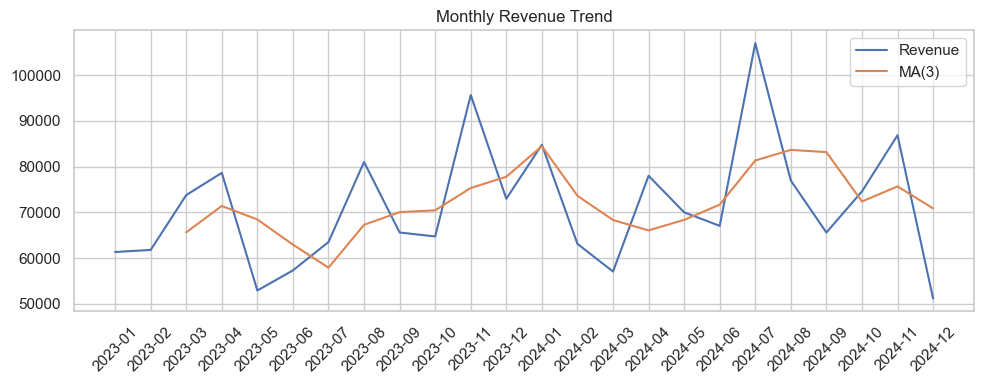

Saved figure: c:\Users\AYUSHITIWARI\FUTURE_DS_01\reports\figures\monthly_revenue_20260123_090445.png


In [13]:
# 9) Time Series Aggregation and Growth
# Daily, weekly, monthly summaries
line_ts = fe_df.copy()
line_ts['date'] = line_ts['order_date'].dt.date

by_day = line_ts.groupby('date', as_index=False).agg(revenue=('line_revenue','sum'), gp=('gross_profit','sum'), orders=('order_id','nunique'))
by_day['revenue_ma7'] = by_day['revenue'].rolling(7).mean()
by_day['revenue_ma28'] = by_day['revenue'].rolling(28).mean()

line_ts['iso_week'] = line_ts['order_date'].dt.isocalendar().week.astype(int)
line_ts['iso_year'] = line_ts['order_date'].dt.isocalendar().year.astype(int)
by_week = line_ts.groupby(['iso_year','iso_week'], as_index=False).agg(revenue=('line_revenue','sum'), gp=('gross_profit','sum'), orders=('order_id','nunique'))

line_ts['month_period'] = line_ts['order_date'].dt.to_period('M')
by_month = line_ts.groupby('month_period', as_index=False).agg(revenue=('line_revenue','sum'), gp=('gross_profit','sum'), orders=('order_id','nunique'))
by_month['month_period'] = by_month['month_period'].astype(str)

# Growth rates helper
def add_growth(df: pd.DataFrame, col: str, new_col: str):
    df = df.sort_index() if not df.index.is_monotonic_increasing else df
    df[new_col] = df[col].pct_change()
    return df

by_month = by_month.sort_values('month_period')
by_month = add_growth(by_month.set_index('month_period'), 'revenue', 'MoM_growth').reset_index()

plt.figure(figsize=(10,4))
plt.plot(by_month['month_period'], by_month['revenue'], label='Revenue')
plt.plot(by_month['month_period'], by_month['revenue'].rolling(3).mean(), label='MA(3)')
plt.xticks(rotation=45)
plt.title('Monthly Revenue Trend')
plt.legend()
plt.tight_layout()
fig_path = Path(CONFIG['figures_dir'])/f'monthly_revenue_{CONFIG["run_ts"]}.png'
plt.savefig(fig_path, dpi=150)
plt.show()
print('Saved figure:', fig_path)

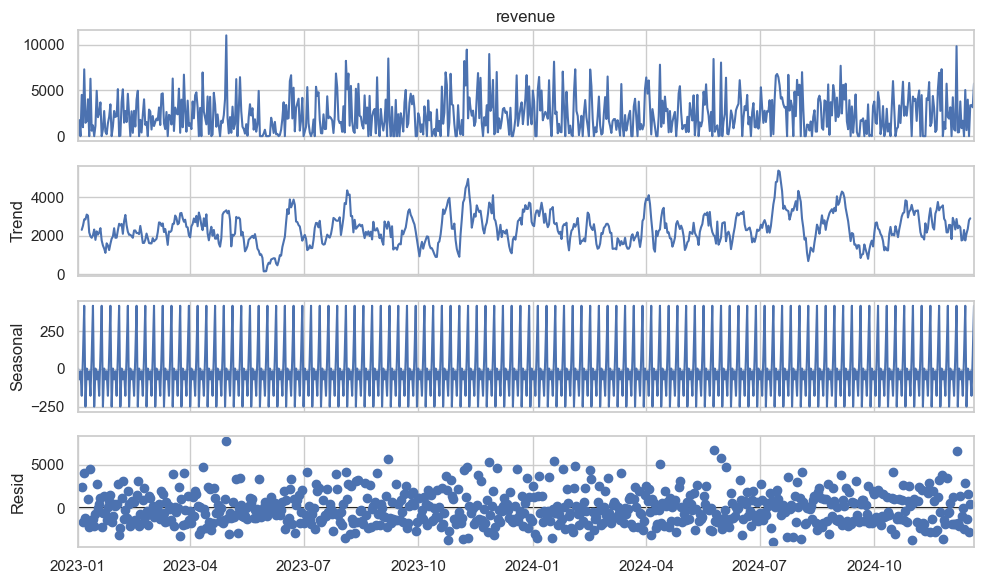

Saved decomposition: c:\Users\AYUSHITIWARI\FUTURE_DS_01\reports\figures\seasonality_decompose_20260123_090445.png


In [14]:
# 10) Seasonality Decomposition (optional)
try:
    daily = by_day.set_index(pd.to_datetime(by_day['date']))['revenue'].asfreq('D').fillna(0)
    res = sm.tsa.seasonal_decompose(daily, model='additive', period=7)
    fig = res.plot()
    fig.set_size_inches(10,6)
    fig.tight_layout()
    fig_path = Path(CONFIG['figures_dir'])/f'seasonality_decompose_{CONFIG["run_ts"]}.png'
    plt.savefig(fig_path, dpi=150)
    plt.show()
    print('Saved decomposition:', fig_path)
except Exception as e:
    print('Seasonality decomposition skipped:', e)

,product_id,revenue,gp,units,orders,revenue_share,cum_share,ABC
678,P943,10206.70820,2887.56880,35,6,0.005963,0.005963,A
673,P936,9961.32020,3111.96020,28,4,0.005820,0.011783,A
340,P520,9115.29460,2626.88460,37,5,0.005326,0.017109,A
228,P382,9040.06980,3010.43980,30,5,0.005282,0.022390,A
301,P472,8673.76660,2865.46660,23,5,0.005068,0.027458,A
244,P401,8542.08160,3670.69160,25,4,0.004991,0.032449,A
529,P759,8361.70332,1758.29332,31,5,0.004885,0.037334,A
179,P321,8333.34050,3306.97050,21,3,0.004869,0.042203,A
581,P818,8155.97080,2337.11080,27,5,0.004765,0.046968,A
688,P956,7871.71950,2711.28950,26,4,0.004599,0.051567,A


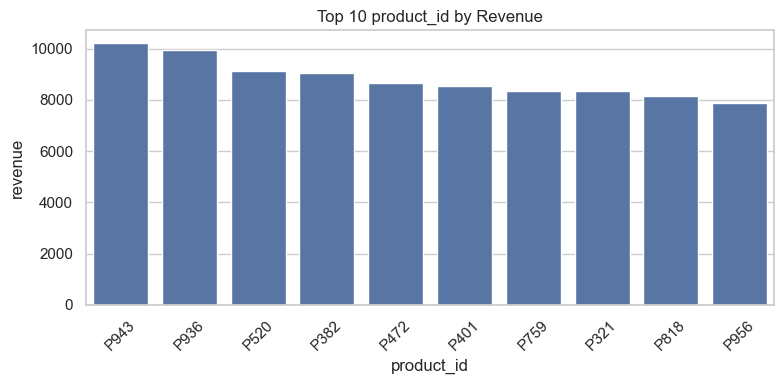

Saved figure: c:\Users\AYUSHITIWARI\FUTURE_DS_01\reports\figures\top10_product_id_20260123_090445.png


,category,revenue,gp,units,orders,revenue_share,cum_share,ABC
0,Furniture,585549.550586,182246.181986,2527,502,0.342104,0.342104,A
1,Office Supplies,570889.337749,178005.475949,2586,492,0.333539,0.675643,A
2,Technology,555172.356328,161449.869028,2469,506,0.324357,1.000000,C


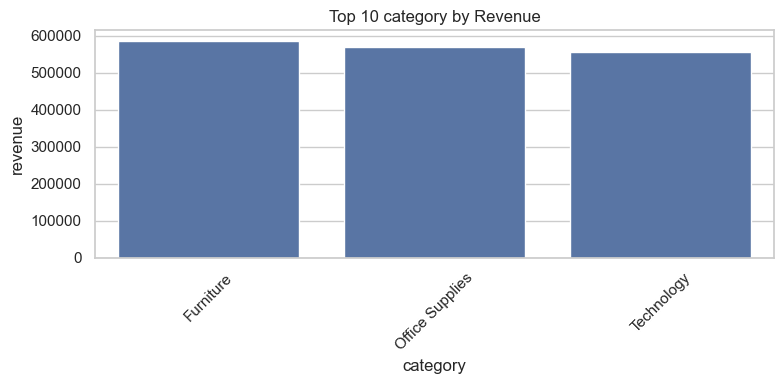

Saved figure: c:\Users\AYUSHITIWARI\FUTURE_DS_01\reports\figures\top10_category_20260123_090445.png


,region,revenue,gp,units,orders,revenue_share,cum_share,ABC
1,East,449389.149380,138966.273180,1898,393,0.262553,0.262553,A
3,West,435637.812548,128189.623948,1936,380,0.254519,0.517072,A
0,Central,414798.190228,123685.539928,1875,367,0.242344,0.759416,A
2,South,411786.092507,130860.089907,1873,360,0.240584,1.000000,C


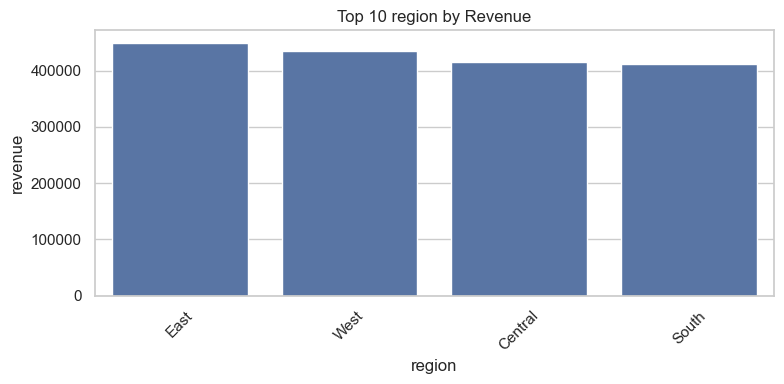

Saved figure: c:\Users\AYUSHITIWARI\FUTURE_DS_01\reports\figures\top10_region_20260123_090445.png


In [15]:
# 11) Product/Category/Region Performance and Pareto
agg_dims = {}
for dim in ['product_id','category','region']:
    if dim in fe_df.columns:
        tmp = fe_df.groupby(dim, as_index=False).agg(
            revenue=('line_revenue','sum'), gp=('gross_profit','sum'), units=('quantity','sum'), orders=('order_id','nunique')
        ).sort_values('revenue', ascending=False)
        tmp['revenue_share'] = tmp['revenue'] / tmp['revenue'].sum()
        tmp['cum_share'] = tmp['revenue_share'].cumsum()
        tmp['ABC'] = pd.cut(tmp['cum_share'], bins=[0,0.8,0.95,1.0], labels=list('ABC'), include_lowest=True)
        agg_dims[dim] = tmp
        display(tmp.head(10))

        plt.figure(figsize=(8,4))
        sns.barplot(x=dim, y='revenue', data=tmp.head(10))
        plt.xticks(rotation=45)
        plt.title(f'Top 10 {dim} by Revenue')
        plt.tight_layout()
        out = Path(CONFIG['figures_dir'])/f'top10_{dim}_{CONFIG["run_ts"]}.png'
        plt.savefig(out, dpi=150)
        plt.show()
        print('Saved figure:', out)

,customer_id,last_order,freq,monetary,recency_days,R,F,M,RFM_Score
0,C1004,2024-08-25,1,777.3192,117,5,1,3,513
1,C1009,2023-10-18,1,1484.9415,429,2,1,4,214
2,C1011,2023-04-03,1,1107.5328,627,1,1,3,113
3,C1014,2024-01-11,1,2658.2256,344,3,1,5,315
4,C1020,2023-10-25,1,28.5348,422,2,1,1,211


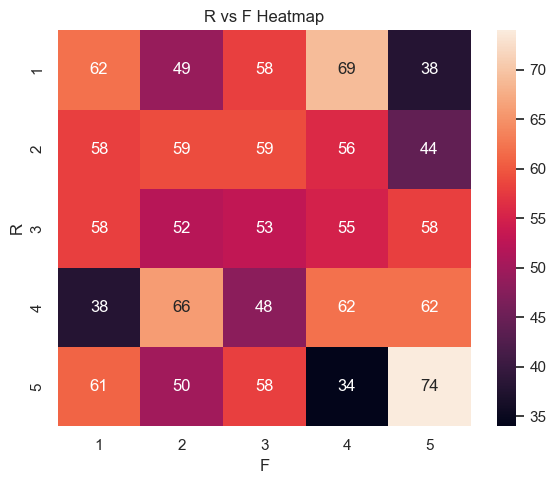

Saved figure: c:\Users\AYUSHITIWARI\FUTURE_DS_01\reports\figures\rfm_heatmap_20260123_090445.png


In [16]:
# 12) Customer RFM Segmentation
rfm_df = None
if 'customer_id' in order_agg.columns:
    end_date = order_agg['order_date'].max()
    cust = order_agg.groupby('customer_id', as_index=False).agg(
        last_order=('order_date','max'), freq=('order_id','nunique'), monetary=('order_revenue','sum')
    )
    cust['recency_days'] = (end_date - cust['last_order']).dt.days
    # Quantile bins 1(low)-5(high)
    cust['R'] = pd.qcut(cust['recency_days'].rank(method='first'), 5, labels=[5,4,3,2,1]).astype(int)
    cust['F'] = pd.qcut(cust['freq'].rank(method='first'), 5, labels=[1,2,3,4,5]).astype(int)
    cust['M'] = pd.qcut(cust['monetary'].rank(method='first'), 5, labels=[1,2,3,4,5]).astype(int)
    cust['RFM_Score'] = cust['R']*100 + cust['F']*10 + cust['M']
    rfm_df = cust
    display(rfm_df.head())

    plt.figure(figsize=(6,5))
    sns.heatmap(pd.crosstab(cust['R'], cust['F']), annot=True, fmt='d')
    plt.title('R vs F Heatmap')
    plt.tight_layout()
    out = Path(CONFIG['figures_dir'])/f'rfm_heatmap_{CONFIG["run_ts"]}.png'
    plt.savefig(out, dpi=150)
    plt.show()
    print('Saved figure:', out)
else:
    print('RFM skipped: customer_id not available')

,discount_band,revenue,units,margin
0,0-5%,545484.069628,2144,0.366211
1,5-10%,444132.713636,1926,0.312384
2,10-20%,581221.015699,2810,0.275757
3,20-30%,134776.620600,670,0.184404
4,>30%,5996.825100,32,-0.087184


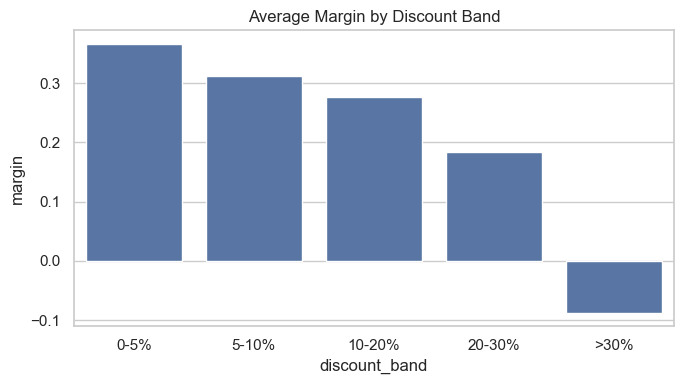

Saved figure: c:\Users\AYUSHITIWARI\FUTURE_DS_01\reports\figures\margin_by_discount_20260123_090445.png
Elasticity (approx): -0.00035752289927574055


In [17]:
# 13) Price and Discount Impact Analysis
# Analyze discount bands and margin impact
fe_df['discount_band'] = pd.cut(fe_df['discount_rate'], bins=[0,0.05,0.1,0.2,0.3,1.0], labels=['0-5%','5-10%','10-20%','20-30%','>30%'], include_lowest=True)
by_disc = fe_df.groupby('discount_band', as_index=False).agg(revenue=('line_revenue','sum'), units=('quantity','sum'), margin=('margin_pct','mean'))
display(by_disc)

plt.figure(figsize=(7,4))
sns.barplot(x='discount_band', y='margin', data=by_disc)
plt.title('Average Margin by Discount Band')
plt.tight_layout()
out = Path(CONFIG['figures_dir'])/f'margin_by_discount_{CONFIG["run_ts"]}.png'
plt.savefig(out, dpi=150)
plt.show()
print('Saved figure:', out)

# Simple elasticity proxy (optional)
try:
    tmp = fe_df.copy()
    tmp = tmp[tmp['unit_price']>0]
    tmp['log_units'] = np.log(tmp['quantity'])
    tmp['log_price'] = np.log(tmp['unit_price'])
    res = sm.OLS(tmp['log_units'], sm.add_constant(tmp['log_price'])).fit()
    print('Elasticity (approx):', res.params['log_price'])
except Exception as e:
    print('Elasticity skipped:', e)

In [18]:
# 14) Simple Forecasting Baselines (monthly revenue)
try:
    m = by_month.copy()
    m['ds'] = pd.to_datetime(m['month_period'] + '-01')
    m = m.sort_values('ds')
    # Train/holdout split
    cutoff = int(len(m)*0.8)
    train, test = m.iloc[:cutoff], m.iloc[cutoff:]
    # Naive forecast: last observed revenue
    naive = test.copy()
    naive['yhat'] = train['revenue'].iloc[-1]
    rmse = np.sqrt(np.mean((naive['yhat'] - test['revenue'])**2))
    mape = np.mean(np.abs((test['revenue'] - naive['yhat'])/np.maximum(test['revenue'],1e-9)))
    print(f'Naive RMSE={rmse:,.0f}, MAPE={mape:.2%}')
except Exception as e:
    print('Forecasting skipped:', e)

Naive RMSE=37,900, MAPE=55.55%


In [19]:
# 15) Anomaly Detection on Sales (daily)
try:
    d = by_day.copy()
    d['date'] = pd.to_datetime(d['date'])
    d = d.sort_values('date')
    # z-score method
    d['z'] = (d['revenue'] - d['revenue'].rolling(28, min_periods=7).mean()) / (d['revenue'].rolling(28, min_periods=7).std()+1e-9)
    anomalies = d[abs(d['z'])>3][['date','revenue','z']]
    display(anomalies.head())
    out = Path(CONFIG['reports_dir'])/f'anomalies_{CONFIG["run_ts"]}.csv'
    anomalies.to_csv(out, index=False)
    print('Saved anomalies to', out)
except Exception as e:
    print('Anomaly detection skipped:', e)

,date,revenue,z
105,2023-04-30,11027.35642,3.540358


Saved anomalies to c:\Users\AYUSHITIWARI\FUTURE_DS_01\reports\anomalies_20260123_090445.csv


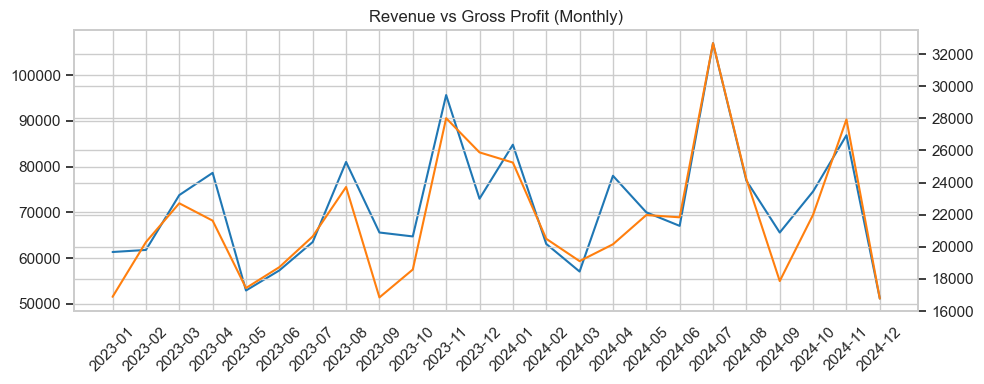

Saved figure: c:\Users\AYUSHITIWARI\FUTURE_DS_01\reports\figures\rev_gp_monthly_20260123_090445.png


In [25]:
# 16) Visualization Utilities and Key Charts
import matplotlib.ticker as mtick

def plot_dual_axis(df, x, y1, y2, title, fname):
    fig, ax1 = plt.subplots(figsize=(10,4))
    ax1.plot(df[x], df[y1], color='tab:blue', label=y1)
    ax2 = ax1.twinx()
    ax2.plot(df[x], df[y2], color='tab:orange', label=y2)
    ax1.set_title(title)
    ax1.set_xticklabels(df[x], rotation=45)
    fig.tight_layout()
    out = Path(CONFIG['figures_dir'])/fname
    plt.savefig(out, dpi=150)
    plt.show()
    print('Saved figure:', out)

# Example usage with by_month if available
if set(['month_period','revenue','gp']).issubset(by_month.columns):
    plot_dual_axis(by_month, 'month_period', 'revenue', 'gp', 'Revenue vs Gross Profit (Monthly)', f'rev_gp_monthly_{CONFIG["run_ts"]}.png')

In [20]:
# 17) Export KPI Summary and Figures + Insights
insights = []

# Example insight rules
if 'category' in fe_df.columns:
    cat_rev = fe_df.groupby('category')['line_revenue'].sum().sort_values(ascending=False)
    if len(cat_rev) >= 1:
        top_cat = cat_rev.index[0]
        share = cat_rev.iloc[0] / cat_rev.sum()
        insights.append(f"Category '{top_cat}' drives {share:.1%} of revenue; protect and grow this line.")

if 'region' in fe_df.columns:
    reg_gp = fe_df.groupby('region')['gross_profit'].sum().sort_values(ascending=False)
    if (reg_gp < 0).any():
        loss_regs = ', '.join(reg_gp[reg_gp<0].index.tolist())
        insights.append(f"Regions with negative profit: {loss_regs}. Investigate pricing, discounts, or logistics.")

# Seasonality peaks
try:
    peak_month = by_month.sort_values('revenue', ascending=False).iloc[0]['month_period']
    insights.append(f"Peak revenue month: {peak_month}. Align promotions and inventory accordingly.")
except Exception:
    pass

# Discount impact
try:
    hi_disc = by_disc.sort_values('margin').iloc[0]
    insights.append(f"Deep discount band '{hi_disc['discount_band']}' correlates with lowest margins. Tighten discount policies.")
except Exception:
    pass

insights_path = Path(CONFIG['reports_dir'])/f'insights_{CONFIG["run_ts"]}.md'
with open(insights_path, 'w') as f:
    f.write('# Insights\n')
    for it in insights:
        f.write(f'- {it}\n')
print('Wrote insights to', insights_path)

# Compact KPI JSON for handoff
kpi_json_path = Path(CONFIG['reports_dir'])/f'kpis_{CONFIG["run_ts"]}.json'
with open(kpi_json_path, 'w') as f:
    json.dump(kpis, f, indent=2)
print('Wrote KPI JSON to', kpi_json_path)

Wrote insights to c:\Users\AYUSHITIWARI\FUTURE_DS_01\reports\insights_20260123_090445.md
Wrote KPI JSON to c:\Users\AYUSHITIWARI\FUTURE_DS_01\reports\kpis_20260123_090445.json


In [21]:
# 18) Unit Tests for Transformations and KPIs
# Sanity checks/assertions
assert (fe_df['line_revenue'] >= 0).all(), 'Negative revenue found'
assert (fe_df['quantity'] > 0).all(), 'Non-positive quantities present after cleaning'
assert fe_df['margin_pct'].max() <= 10, 'Margin% suspiciously high; check inputs'
assert order_agg['order_id'].is_unique, 'Duplicate order_ids in order-level aggregation'

print('Basic unit tests passed.')

Basic unit tests passed.


In [22]:
# 19) Performance and Memory Optimization (quick tips)
# Downcast numeric types to save memory
opt_df = fe_df.copy()
for c in ['quantity']:
    if c in opt_df.columns:
        opt_df[c] = pd.to_numeric(opt_df[c], downcast='integer')
for c in ['unit_price','unit_cost','net_price','line_revenue','line_cogs','gross_profit']:
    if c in opt_df.columns:
        opt_df[c] = pd.to_numeric(opt_df[c], downcast='float')
print('Applied dtype downcasting to selected columns.')

Applied dtype downcasting to selected columns.


In [23]:
# 20) Optional: SQL I/O and Parameterized Runs (demo only)
try:
    import sqlite3
    db_path = Path(CONFIG['processed_dir'])/f'sales_{CONFIG["run_ts"]}.sqlite'
    with sqlite3.connect(db_path) as conn:
        fe_df.head(1000).to_sql('sales_line', conn, if_exists='replace', index=False)
        order_agg.to_sql('sales_order', conn, if_exists='replace', index=False)
    print('Wrote sample tables to', db_path)
except Exception as e:
    print('SQL I/O skipped:', e)

# Parameterized runs hint: Use CONFIG start_date/end_date to subset reporting window

Wrote sample tables to c:\Users\AYUSHITIWARI\FUTURE_DS_01\data\sales_20260123_090445.sqlite


In [24]:
# 21) Optional: Basic Data Privacy
# Hash customer_id before external export (demo)
try:
    import hashlib
    if 'customer_id' in fe_df.columns:
        salt = 'replace_with_env_secret'
        fe_df['customer_hash'] = fe_df['customer_id'].fillna('NA').apply(lambda x: hashlib.sha256((salt+str(x)).encode()).hexdigest())
        print('Computed customer_hash (keep salt outside repo).')
except Exception as e:
    print('Privacy step skipped:', e)

Computed customer_hash (keep salt outside repo).


## Recommendations (Business-Focused)
- Price & Discount: Tighten high-discount policies where margins are weak; use targeted promotions on high-LTV segments.
- Inventory: Prioritize top A products by revenue share; ensure availability ahead of peak months.
- Regional Focus: Double down on regions with strongest profitability; fix or exit persistently loss-making areas.
- Product Mix: Expand adjacent SKUs in top categories; bundle slow-movers with bestsellers.
- Customer Growth: Retention plays for high RFM segments; welcome offers to convert low-frequency buyers.
- Operations: Review shipping/returns costs in low-margin items to recover profit.


## Dashboard Guidance (Power BI / Tableau / Excel)
Recommended visuals and layout:
- KPI Cards: Total Revenue, Total Profit, Margin %, Total Orders, AOV, Customers
- Trend Line (Monthly): Revenue with 3-month MA overlay; optional YoY
- Profit vs Sales: Dual-axis chart by month
- Category & Region Bars: Revenue and Profit (sorted); filter by month/region/category
- Top Products: Top 10 by Revenue; include margin color/tooltip
- Discount Impact: Margin by Discount Band; slicer for Category
- Slicers/Filters: Date range, Category, Region, Channel, Customer Segment (RFM)
Layout tips:
- Place KPI cards on top; trends center-left; bars center-right; products below; filters on the left panel.

## Appendix
- Limitations: Sample data is synthetic if no real CSV is provided; metrics change once real data is loaded.
- How to use a Kaggle dataset: Download CSV, ensure required columns (see schema cell), save as data/sales.csv, rerun notebook.
- Next steps: Add cohort retention, CLV modeling, marketing channel attribution, and product affinity analysis.
- Reproducibility: Manifest JSON and versioned outputs are saved with timestamps for traceability.